<a href="https://colab.research.google.com/github/Greeshma-babu/AI_Projects/blob/main/Image_Clustering_Using_KMeans_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
import cv2
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Clustering_Tom_Jerry.zip to Clustering_Tom_Jerry.zip


In [8]:
!unzip Clustering_Tom_Jerry.zip

Archive:  Clustering_Tom_Jerry.zip
   creating: Clustering_Tom_Jerry/
  inflating: Clustering_Tom_Jerry/9593500-tom.jpg  
  inflating: Clustering_Tom_Jerry/images (1).jpg  
  inflating: Clustering_Tom_Jerry/images (1).png  
  inflating: Clustering_Tom_Jerry/images (10).jpg  
  inflating: Clustering_Tom_Jerry/images (11).jpg  
  inflating: Clustering_Tom_Jerry/images (12).jpg  
  inflating: Clustering_Tom_Jerry/images (13).jpg  
  inflating: Clustering_Tom_Jerry/images (14).jpg  
  inflating: Clustering_Tom_Jerry/images (15).jpg  
  inflating: Clustering_Tom_Jerry/images (16).jpg  
  inflating: Clustering_Tom_Jerry/images (17).jpg  
  inflating: Clustering_Tom_Jerry/images (18).jpg  
  inflating: Clustering_Tom_Jerry/images (19).jpg  
  inflating: Clustering_Tom_Jerry/images (2).jpg  
  inflating: Clustering_Tom_Jerry/images (2).png  
  inflating: Clustering_Tom_Jerry/images (20).jpg  
  inflating: Clustering_Tom_Jerry/images (21).jpg  
  inflating: Clustering_Tom_Jerry/images (22).jpg 

In [31]:
import numpy as np
datasets = "/content/Clustering_Tom_Jerry"
images = []
image_names = []
for image in os.listdir(datasets):
    img = cv2.imread(os.path.join(datasets,image))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img = cv2.resize(img,(224,224))
    img = img.flatten()
    images.append(img)
    image_names.append(image)
X = np.array(images)
print(X.shape)


(40, 150528)


In [32]:
x_scaler = StandardScaler()
x_scaled = x_scaler.fit_transform(X)
print(x_scaled)

[[ 0.52203197  0.5920357   0.57876263 ...  0.58760833  0.65899611
   0.66232164]
 [ 0.52203197  0.5920357   0.57876263 ...  0.58760833  0.65899611
   0.66232164]
 [-0.98640668 -1.2150257  -1.62096249 ... -0.86841231 -1.22238124
  -1.45866429]
 ...
 [ 0.52203197  0.5920357   0.57876263 ...  0.58760833  0.65899611
   0.66232164]
 [-0.53761501 -1.9289265  -1.6636756  ... -1.28441821 -0.54385171
  -1.20570267]
 [ 0.52203197  0.5920357   0.57876263 ...  0.58760833  0.65899611
   0.66232164]]


In [33]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
print(x_pca.shape)

(40, 2)


In [34]:
kmeans = KMeans(n_clusters=2)
label  = kmeans.fit_predict(x_pca)
print(label)

[0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0
 0 1 0]


In [39]:
class_name = ['Tom', 'Jerry']
for i in label:
  print(class_name[i])

Tom
Tom
Jerry
Tom
Jerry
Tom
Tom
Jerry
Jerry
Tom
Tom
Tom
Tom
Tom
Tom
Tom
Tom
Tom
Tom
Jerry
Jerry
Tom
Jerry
Tom
Tom
Tom
Jerry
Jerry
Tom
Tom
Tom
Tom
Tom
Tom
Tom
Jerry
Tom
Tom
Jerry
Tom


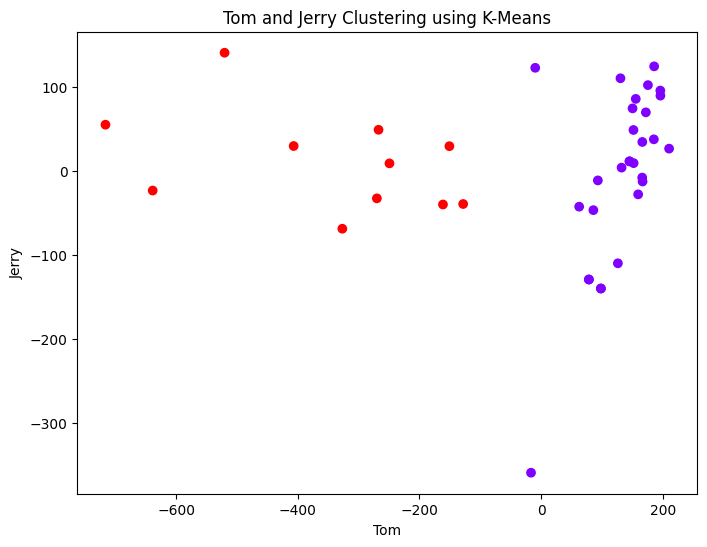

In [36]:
pca2 = PCA(n_components=2)

X_2D = pca2.fit_transform(x_pca)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(
    X_2D[:,0],
    X_2D[:,1],
    c=label,
    cmap="rainbow"
)

plt.title("Tom and Jerry Clustering using K-Means")
plt.xlabel("Tom")
plt.ylabel("Jerry")
plt.show()

In [41]:
import pandas as pd

class_labels = [class_name[i] for i in label]


df = pd.DataFrame({
    "Filename": image_names,
    "Cluster": label,
    "Name" : class_labels
})

print(df)

           Filename  Cluster   Name
0    images (7).jpg        0    Tom
1   images (32).jpg        0    Tom
2   images (21).jpg        1  Jerry
3   images (25).jpg        0    Tom
4   images (13).jpg        1  Jerry
5    images (5).png        0    Tom
6   images (18).jpg        0    Tom
7   images (10).jpg        1  Jerry
8   images (31).jpg        1  Jerry
9   images (20).jpg        0    Tom
10  images (27).jpg        0    Tom
11  images (19).jpg        0    Tom
12   images (1).png        0    Tom
13  images (16).jpg        0    Tom
14   images (5).jpg        0    Tom
15   images (4).png        0    Tom
16  images (23).jpg        0    Tom
17  images (15).jpg        0    Tom
18  images (14).jpg        0    Tom
19  images (12).jpg        1  Jerry
20   images (9).jpg        1  Jerry
21   images (1).jpg        0    Tom
22  9593500-tom.jpg        1  Jerry
23  images (11).jpg        0    Tom
24   images (3).png        0    Tom
25   images (8).jpg        0    Tom
26   images (2).jpg        1